# Setup

In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import logging
import tpvalidator.mcprod.workspace as workspace
import tpvalidator.utilities as utils
import tpvalidator.mcprod.analyzers.snn as snn

from rich import print
from tpvalidator.utilities import temporary_log_level, pandas_backend

from collections import OrderedDict

## Code

In [3]:
def make_wins(tps: pd.DataFrame, ro_view: int):
    summary = (
        tps
        .query(f'readout_view == {ro_view}')
        .groupby(['event_uid', 'TPCSetID', 'tawin_id'], sort=False)
        .agg(
            n_entries=('tawin_id', "size"),
            sadc=("adc_integral", "sum"),
        )
        .reset_index()
    )

    return summary




## Data

In [4]:
import tpvalidator.datasets.miniprod as miniprod

datasets = miniprod.load_mc_datasets()

Key 'triggerAna/mcneutrinos' not found in file.
Key 'triggerAna/mcparticles' not found in file.
Key 'triggerAna/simides' not found in file.


Dataset e-minus: 4920 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x6ref'},
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Dataset gamma: 4950 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x6ref'},
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Dataset mu-minus: 4930 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x6ref'},
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Dataset radiols: 9930 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x6ref'},
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

/var/folders/dw/sj94s2457kl2gkb829ty4_cc0000gn/T/ipykernel_3658/2615817058.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  rad_tps.hist(ax=ax)


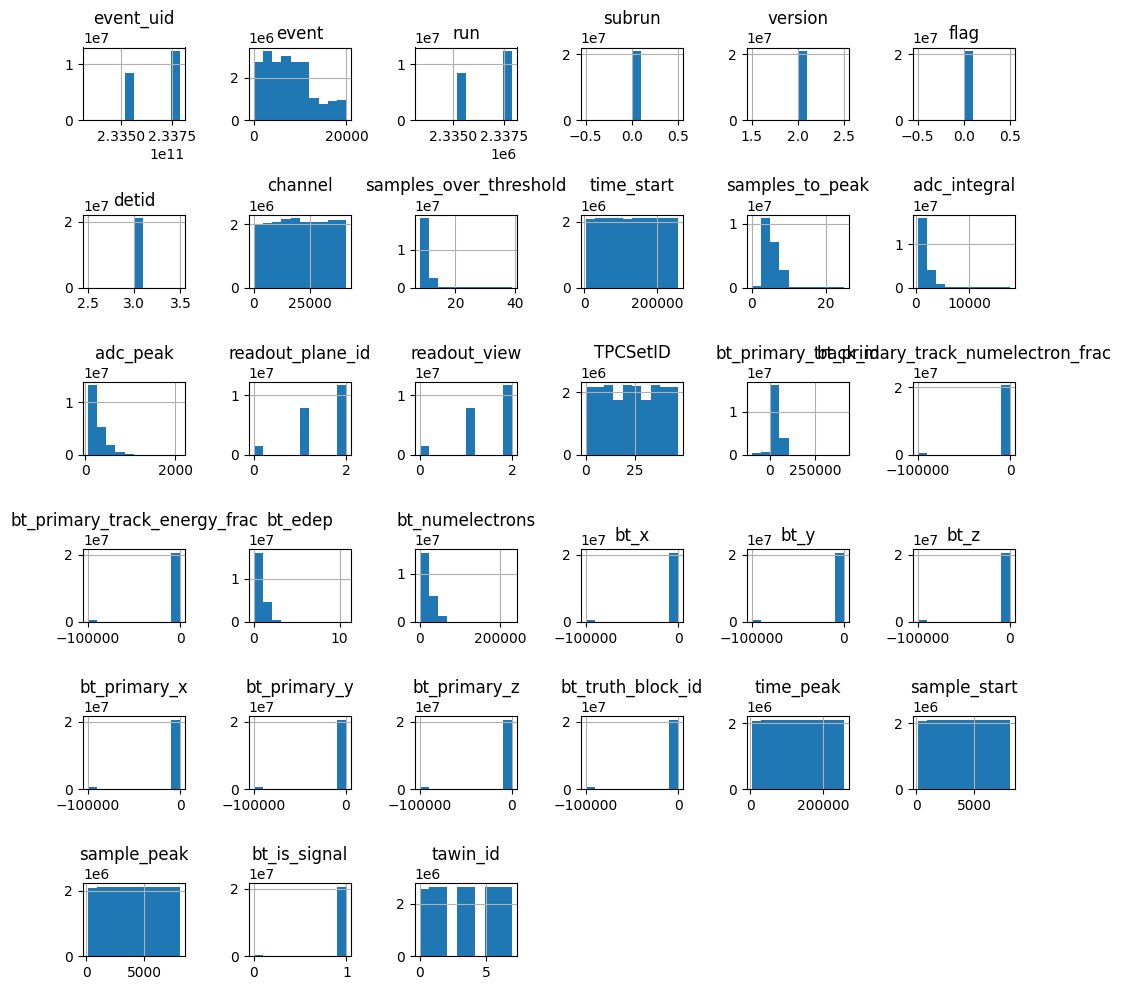

In [184]:
rad_tps = datasets['radbkg'].tps

fig, ax = plt.subplots(figsize=(10,10))
rad_tps.hist(ax=ax)
fig.tight_layout()

In [ ]:
from typing import Tuple, Optional, Union, Sequence, Dict, List
from rich.table import Table
from tpvalidator.mcprod.geometry import FDVDGeometry_1x6x8

def make_rates_table_from_dataframes(
        datasets : Dict[str,pd.DataFrame],
        preselection: str = '',
        per:str='chan',
        title: str='',
        ro_win_len: int=None,
        sampling_period=0.5e-6
        ) -> Table:

    num_el_map = {
        'chan' : lambda v: FDVDGeometry_1x6x8.crp_num_chans_by_view_sim(v)*FDVDGeometry_1x6x8.num_crps,
        'crp' : lambda _: FDVDGeometry_1x6x8.num_crps,
        'tpc' : lambda _: FDVDGeometry_1x6x8.num_tpcs,
        'det' : lambda _: 1,
        'fdvd' : lambda _: FDVDGeometry_1x6x8.num_crps/160,
    }

    num_el = num_el_map[per]

    t = Table('sample', 'time', 'U', 'V', 'X', title=title)
    for s, df in datasets.items():
        # num_ev = num_events
        num_ev = df.extra_info['num_events']

        
        # Throw if not available
        ro_win_len = df.extra_info['readout_window'] if ro_win_len is None else ro_win_len

        total_time = num_ev*ro_win_len*sampling_period
        row = [s, f'{total_time:.3f} s']
        tps_sel = df.query(preselection) if preselection else df
        for v in range(3):
            num_els = num_el(v)
            noise_rate = len(tps_sel.query(f'readout_view == {v}'))/total_time/num_els
            row += [f'{noise_rate:.2f} Hz']
        t.add_row(*row)
    return t

In [187]:
rad_tps_by_gen = sorted([(n if n else 'Noise',df) for n,df in rad_tps.groupby('bt_generator_name')], reverse=True, key=lambda x: len(x[1]))


In [211]:
0.5e-6*8000

0.004

In [193]:

print(make_vd_rates_table_2(OrderedDict(rad_tps_by_gen), 100, per='crp', title='Rates per CRP'))


N_ev = 100, Rwadout win length 8000, Total time 4.0

N_ev = 100, Rwadout win length 8000, Total time 4.0

N_ev = 100, Rwadout win length 8000, Total time 4.0

N_ev = 100, Rwadout win length 8000, Total time 4.0

N_ev = 100, Rwadout win length 8000, Total time 4.0

...

N_ev = 100, Rwadout win length 8000, Total time 4.0

N_ev = 100, Rwadout win length 8000, Total time 4.0

N_ev = 100, Rwadout win length 8000, Total time 4.0

N_ev = 100, Rwadout win length 8000, Total time 4.0

                                         Rates per CRP                                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ sample                                 ┃ time    ┃ U           ┃ V            ┃ X            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ CavernwallGammasAtLAr1x8x6             │ 4.000 s │ 23855.10 Hz │ 133083.58 Hz │ 173011.81 Hz │
│ Ar39GenInLAr                           │ 4.000 s │ 45.04 Hz    │ 2699.04 Hz   │ 33558.33 Hz  │
│ Th232ChainGenInCathode                 │ 4.000 s │ 2838.21 Hz  │ 4071.10 Hz   │ 6896.94 Hz   │
│ foamGammasAtLAr1x8x6                   │ 4.000 s │ 598.90 Hz   │ 5555.69 Hz   │ 7227.90 Hz   │
│ Th232ChainGenInAnode                   │ 4.000 s │ 1512.96 Hz  │ 4878.19 Hz   │ 6083.56 Hz   │
│ Kr85GenInLAr                           │ 4.000 s │ 6.10 Hz     │ 1574.12 Hz   │ 9650.73 Hz   │
│ Noise                                  │ 4.000 s │ 1573.00 Hz  │ 8236.25 Hz   │ 16.77 Hz     │
│ U238ChainGenInAnode                    │ 4.000 s │ 228.25 Hz   │ 1687.12 Hz   │ 2187.56 Hz   │
│ U238ChainGenInCathode                  │ 4.000 s │ 290.31 Hz   │ 595.35 Hz    │ 1402.75 Hz   │
│ Rn222ChainBi214GenInLAr                │ 4.000 s │ 129.98 Hz   │ 336.94 Hz    │ 557.90 Hz    │
│ Rn222ChainFromBi214GenInUpperMesh1x8x6 │ 4.000 s │ 138.92 Hz   │ 254.29 Hz    │ 556.25 Hz    │
│ Rn220ChainFromPb212GenInUpperMesh1x8x6 │ 4.000 s │ 175.58 Hz   │ 269.67 Hz    │ 489.40 Hz    │
│ K40GenInAnode                          │ 4.000 s │ 11.94 Hz    │ 386.00 Hz    │ 515.12 Hz    │
│ Rn220ChainPb212GenInLAr                │ 4.000 s │ 126.83 Hz   │ 249.33 Hz    │ 342.96 Hz    │
│ K40GenInCathode                        │ 4.000 s │ 29.02 Hz    │ 99.40 Hz     │ 267.58 Hz    │
│ K42From42ArGenInUpperMesh1x8x6         │ 4.000 s │ 44.71 Hz    │ 62.40 Hz     │ 98.46 Hz     │
│ Rn222ChainFromBi210GenInUpperMesh1x8x6 │ 4.000 s │ 0.79 Hz     │ 8.04 Hz      │ 69.17 Hz     │
│ Rn222ChainPb214GenInLAr                │ 4.000 s │ 0.23 Hz     │ 12.58 Hz     │ 61.69 Hz     │
│ K42From42ArGenInLAr                    │ 4.000 s │ 11.56 Hz    │ 19.96 Hz     │ 25.04 Hz     │
│ Rn222ChainFromPb214GenInUpperMesh1x8x6 │ 4.000 s │ 0.04 Hz     │ 0.85 Hz      │ 8.83 Hz      │
│ Ar42GenInLAr                           │ 4.000 s │ 0.00 Hz     │ 0.44 Hz      │ 5.02 Hz      │
│ Rn222ChainRn222GenInLAr                │ 4.000 s │ 0.02 Hz     │ 0.15 Hz      │ 0.33 Hz      │
│ Rn222ChainPo218GenInLAr                │ 4.000 s │ 0.06 Hz     │ 0.17 Hz      │ 0.25 Hz      │
│ Rn222ChainFromPb210GenInUpperMesh1x8x6 │ 4.000 s │ 0.02 Hz     │ 0.04 Hz      │ 0.15 Hz      │
│ Rn222ChainPb210GenInLAr                │ 4.000 s │ 0.00 Hz     │ 0.06 Hz      │ 0.04 Hz      │
└────────────────────────────────────────┴─────────┴─────────────┴──────────────┴──────────────┘

# Activity Search Windows

In [ ]:
em_tps = datasets['e-minus'].tps
rad_tps = datasets['radbkg'].tps
print(len(em_tps))
print(len(rad_tps))
# em_tps = datasets['e-minus'].tps.query('adc_peak > 100').copy()
# rad_tps = datasets['radbkg'].tps.query('adc_peak > 100').copy()
# print(len(em_tps))
# print(len(rad_tps))

win_size = 1000 # samples

em_tps['tawin_id'] = (em_tps.sample_peak - 100) // win_size
rad_tps['tawin_id'] = (rad_tps.sample_peak - 100) // win_size

264689

21059179

254261

19389928

<Axes: >

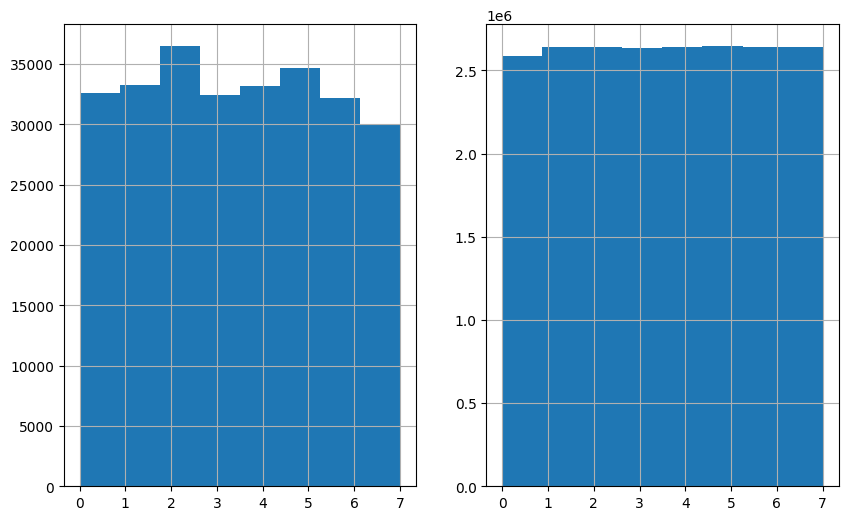

In [171]:
fig, axes = plt.subplots(1,2, figsize=(10,6))

em_tps.tawin_id.hist(bins=len(em_tps.tawin_id.unique()), ax=axes[0])
rad_tps.tawin_id.hist(bins=len(rad_tps.tawin_id.unique()), ax=axes[1])

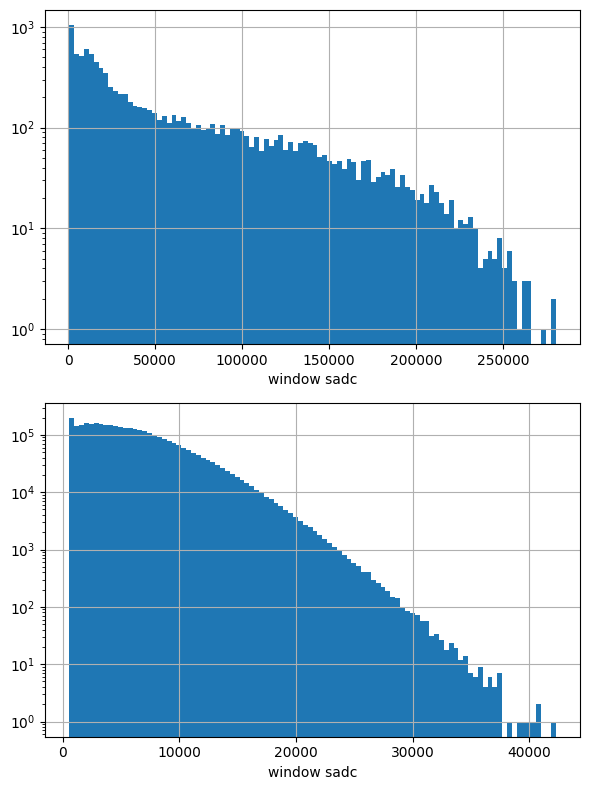

In [177]:
# 
fig, axes = plt.subplots(2,1, figsize=(6,8))

ax=axes[0]
em_wins = make_wins(em_tps, 2)
em_wins.sadc.hist(ax=ax, bins=100)
ax.set_yscale('log')
ax.set_xlabel('window sadc')


ax=axes[1]
rad_wins = make_wins(rad_tps, 2)
rad_wins.sadc.hist(ax=ax, bins=100)
ax.set_yscale('log')
ax.set_xlabel('window sadc')

# ax.set_yscale('log')

# make_wins(rad_tps, 2)

fig.tight_layout()

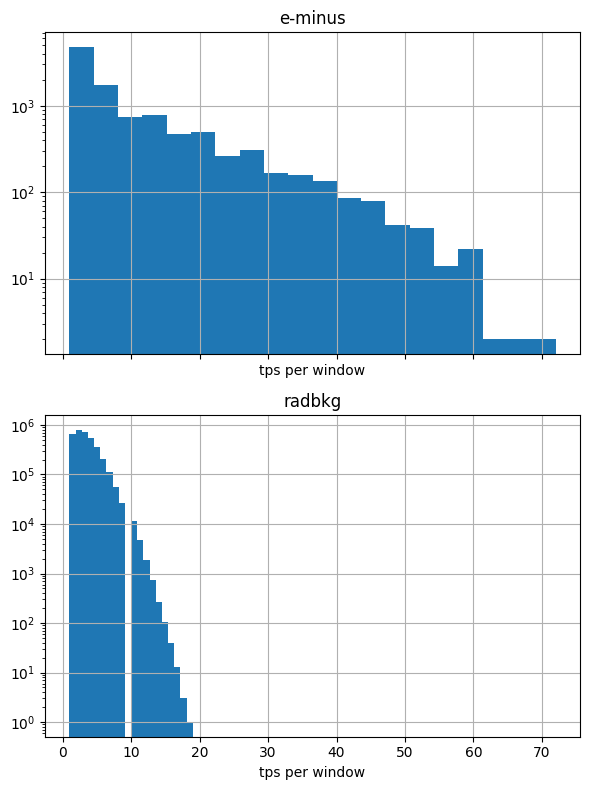

In [169]:
fig, axes = plt.subplots(2,1, figsize=(6,8), sharex=True)

ax=axes[0]
em_wins = make_wins(em_tps, 2)
em_wins.n_entries.hist(ax=ax, bins=20)
ax.set_yscale('log')
ax.set_xlabel('tps per window')
ax.set_title('e-minus')

ax=axes[1]
rad_wins = make_wins(rad_tps, 2)
rad_wins.n_entries.hist(ax=ax, bins=20)
ax.set_yscale('log')
ax.set_xlabel('tps per window')
ax.set_title('radbkg')
# ax.set_yscale('log')

fig.tight_layout()

Number of actiity search windows: 3511703

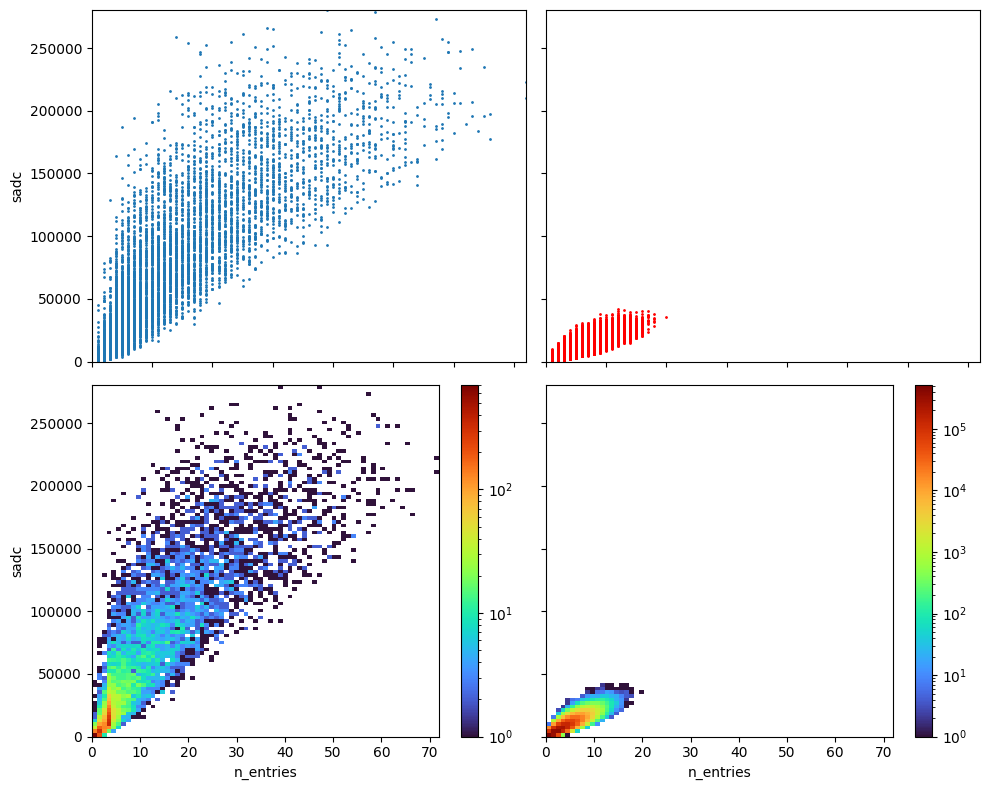

In [26]:
from matplotlib.colors import LogNorm

print(f"Number of actiity search windows: {len(rad_wins)}")

fig, axes = plt.subplots(2, 2, figsize=(10,8), sharex=True, sharey=True)
ax=axes[0][0]
em_wins.plot.scatter(x='n_entries', y='sadc', ax=ax, s=1)
ax.set_xlabel('n_entries')
ax.set_ylabel('sadc')

ax=axes[0][1]
rad_wins.plot.scatter(x='n_entries', y='sadc', ax=ax, c='r', s=1)
ax.set_xlabel('n_entries')
ax.set_ylabel('sadc')

# fig, axes = plt.subplots(1, 2, figsize=(13,6), sharex=True, sharey=True)
# bins= np.linspace(0,70,70),100
xmax = max(em_wins.n_entries.max(), rad_wins.n_entries.max())
ymax = max(em_wins.sadc.max(), rad_wins.sadc.max())
bins=(np.linspace(0,xmax,xmax), np.linspace(0,ymax,100))
cmap='turbo'
# cmap='viridis'
ax = axes[1][0]
h = ax.hist2d(em_wins['n_entries'], em_wins['sadc'], bins=bins, cmap=cmap, norm=LogNorm())
fig.colorbar(h[3], ax=ax)
ax.set_xlabel('n_entries')
ax.set_ylabel('sadc')

ax = axes[1][1]
h = ax.hist2d(rad_wins['n_entries'], rad_wins['sadc'], bins=bins, cmap=cmap, norm=LogNorm())
fig.colorbar(h[3], ax=ax)
ax.set_xlabel('n_entries')
ax.set_ylabel('sadc')

# h = ax.hist2d(em_wins['n_entries'], em_wins['sadc'], bins=bins, cmap=cmap, weights=w, norm=LogNorm())
fig.tight_layout()

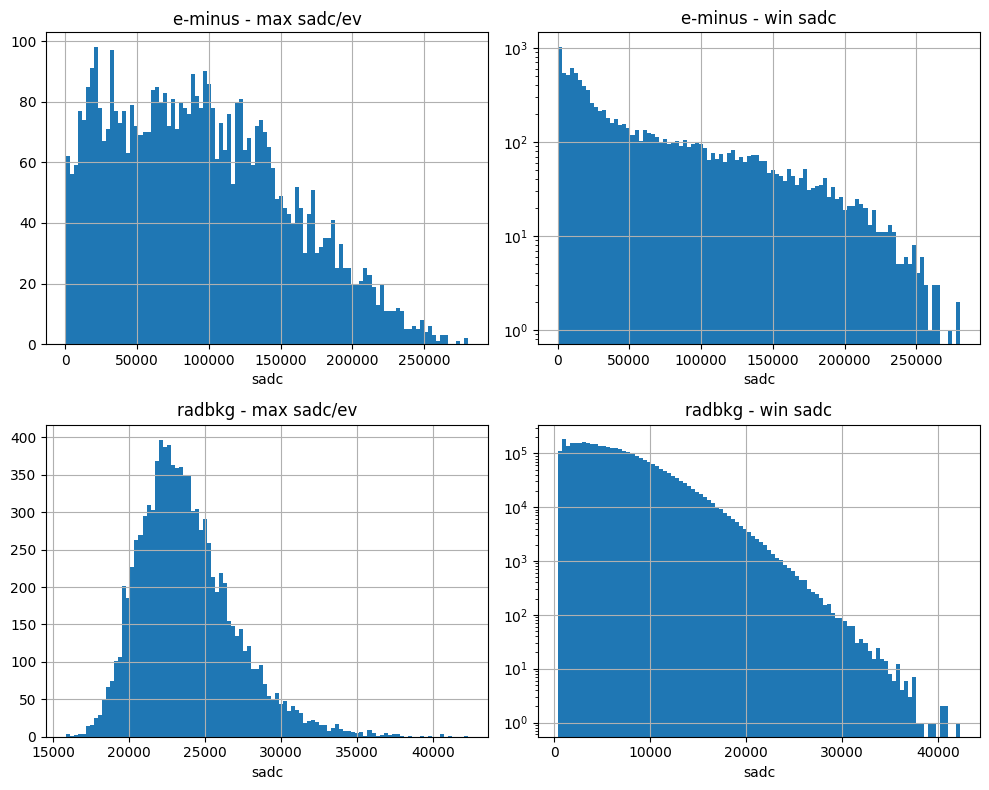

In [135]:
fig, axes = plt.subplots(2,2, figsize=(10,8))

ax=axes[0][0]
(em_wins
#  .query('sadc > 4000')
 .groupby('event_uid', sort=False)
 .agg(
    sadc_max=('sadc', "max"),
    n_win=('tawin_id', "size"),
    )
).sadc_max.hist(bins=100, ax=ax)

ax.set_title('e-minus - max sadc/ev')
ax.set_xlabel('sadc')

ax=axes[1][0]

(rad_wins
#  .query('sadc > 4000')
 .groupby('event_uid', sort=False)
 .agg(
    sadc_max=('sadc', "max"),
    n_win=('tawin_id', "size"),
    )
).sadc_max.hist(bins=100, ax=ax)

ax.set_title('radbkg - max sadc/ev')
ax.set_xlabel('sadc')


ax=axes[0][1]
em_wins.sadc.hist(bins=100, ax=ax)
ax.set_yscale('log')
ax.set_xlabel('sadc')
ax.set_title('e-minus - win sadc')


ax=axes[1][1]
rad_wins.sadc.hist(bins=100, ax=ax)
ax.set_yscale('log')
ax.set_xlabel('sadc')
ax.set_title('radbkg - win sadc')

fig.tight_layout()


# TA finding

In [36]:
rad_tps.extra_info['num_events']*rad_tps.extra_info['readout_window']*0.5e-6

39.72

3482614, 1092443

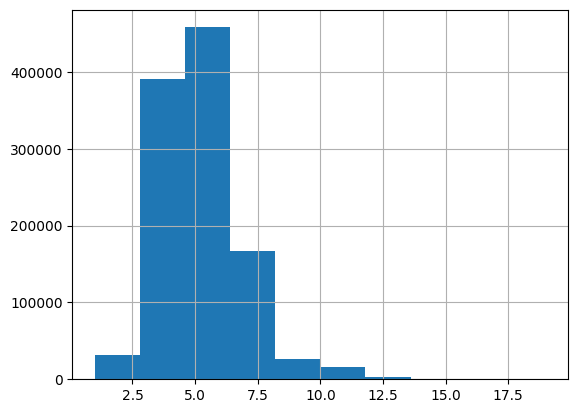

In [ ]:
from tpvalidator.tafinder.dbscan import ApplyDBScan
def apply_dbscan_wrap(*args, **kwargs):
    n_clusters, mean_cluster_sadc, total_cluster_sadc, max_cluster_sadc = ApplyDBScan(*args, **kwargs)
    return pd.Series({
        "n_clusters": n_clusters,
        "mean_cluster_sadc": mean_cluster_sadc,
        "total_cluster_sadc": total_cluster_sadc,
        "max_cluster_sadc": max_cluster_sadc,
    })

### Create radiological windows and calculate entries and sum adc for each

tps = rad_tps
ro_view = 2
wins = (
    tps.query(f'readout_view == {ro_view}')
    .groupby(['event_uid', 'TPCSetID', 'tawin_id'], sort=False)
    .agg(
        n_entries=('tawin_id', "size"),
        sadc=("adc_integral", "sum"),
    )

)

# Filter windows in the inspect region
sel_wins = wins.query('sadc > 7500 & sadc < 50000')
sel_wins.n_entries.hist()
print(f"{len(wins)}, {len(sel_wins)}")

In [165]:
keys = ['event_uid', 'TPCSetID', 'tawin_id']


filtered = tps.join(sel_wins.index.to_frame(index=False).assign(_keep=True).set_index(keys),
                   on=keys)
filtered = filtered[filtered["_keep"] == True]
print(f'tps count = {len(tps)}, filtered tps count {len(filtered)}')

tps count = 21059179, filtered tps count 11280284

In [18]:
print(filtered.query(f'readout_view == {ro_view}').groupby(['event_uid', 'TPCSetID', 'tawin_id'], sort=False).ngroups)

138275

In [ ]:
# from tqdm import tqdm
# tqdm.pandas(desc="my bar!")


# tas2 = (
#     filtered
#     .query(f'readout_view == {ro_view}')
#     .groupby(['event_uid', 'TPCSetID', 'tawin_id'], sort=False)
#     .progress_apply(apply_dbscan_wrap, include_groups = False)
#     .reset_index()
# )

numba tafinder!: 100%|██████████| 46498/46498 [14:35<00:00, 53.10it/s]


In [55]:
from tpvalidator.tafinder.trigger_algs_numba import apply_dbscan
from tqdm import tqdm
tqdm.pandas(desc="numba tafinder!")

### Create radiological windows and calculate entries and sum adc for each

tas3 = (
    filtered
    .query(f'readout_view == {ro_view}')
    .groupby(['event_uid', 'TPCSetID', 'tawin_id'], sort=False)
    .progress_apply(apply_dbscan, include_groups = False)
    .reset_index()
)

numba tafinder!: 100%|██████████| 1110125/1110125 [02:38<00:00, 6994.34it/s]


In [56]:
tas3

# print(tas3.n_clusters.max())
# tas3.n_clusters.hist(bins=int(tas3.n_clusters.max()))

,event_uid,TPCSetID,tawin_id,n_clusters,mean_cluster_sadc,total_cluster_sadc,max_cluster_sadc
0,233339401031,0,5,0.0,0.0,0.0,0.0
1,233339401031,0,6,0.0,0.0,0.0,0.0
2,233339401031,0,0,0.0,0.0,0.0,0.0
3,233339401031,1,3,1.0,2271.0,2271.0,2271.0
4,233339401031,1,1,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
1110120,233789400095,45,6,0.0,0.0,0.0,0.0
1110121,233789400095,46,3,0.0,0.0,0.0,0.0
1110122,233789400095,46,2,0.0,0.0,0.0,0.0
1110123,233789400095,47,5,0.0,0.0,0.0,0.0


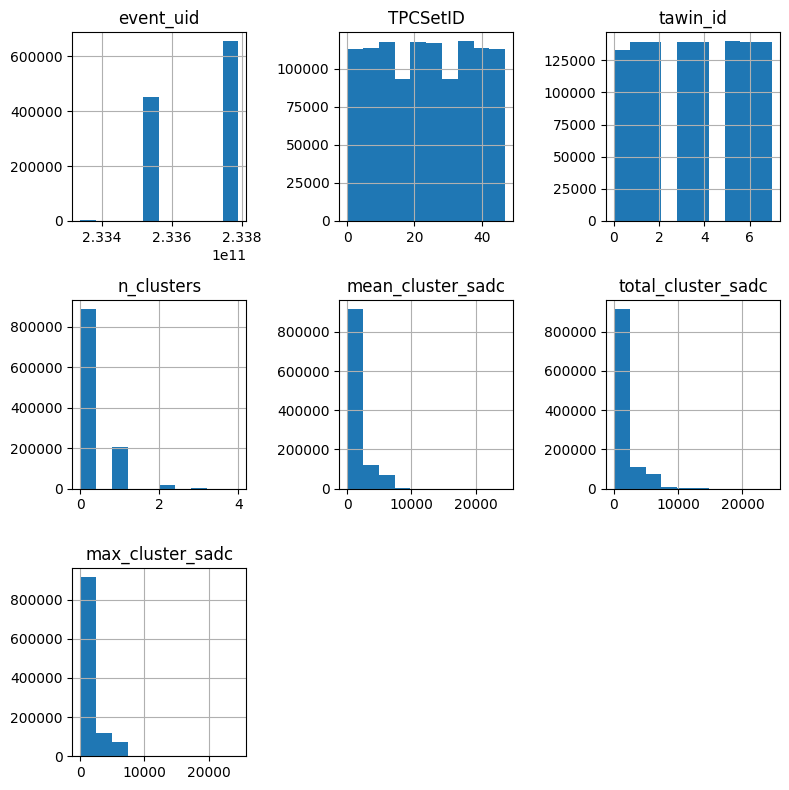

In [57]:
tas3.hist(figsize=(8,8))
plt.tight_layout()

(array([[2.1200e+02, 1.2550e+03, 2.3580e+03, 4.3900e+03, 6.5850e+03,
         8.6170e+03, 9.9690e+03, 1.1079e+04, 1.1766e+04, 1.2368e+04,
         1.2534e+04, 1.0793e+04, 1.0547e+04, 1.0740e+04, 1.0465e+04,
         7.9070e+03, 6.9460e+03, 6.8900e+03, 6.9420e+03, 6.9010e+03,
         6.8570e+03, 6.8530e+03, 6.8260e+03, 7.1700e+03, 7.4620e+03,
         6.6120e+03, 4.2190e+03, 1.4550e+03, 2.5900e+02, 7.3000e+01,
         4.1000e+01, 2.0000e+01, 1.1000e+01, 7.0000e+00, 9.0000e+00,
         6.0000e+00, 6.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00,
         1.0000e+00, 2.0000e+00, 0.0000e+00, 1.0000e+00, 2.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0

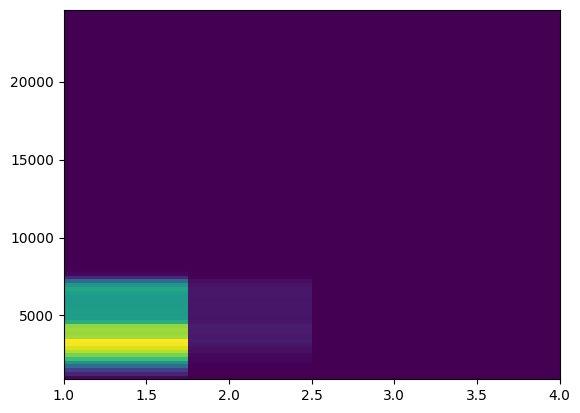

In [126]:
df = tas3.query('n_clusters > 0')

plt.hist2d(x=df.n_clusters.values, y=df.max_cluster_sadc.values,bins=(4, 100))



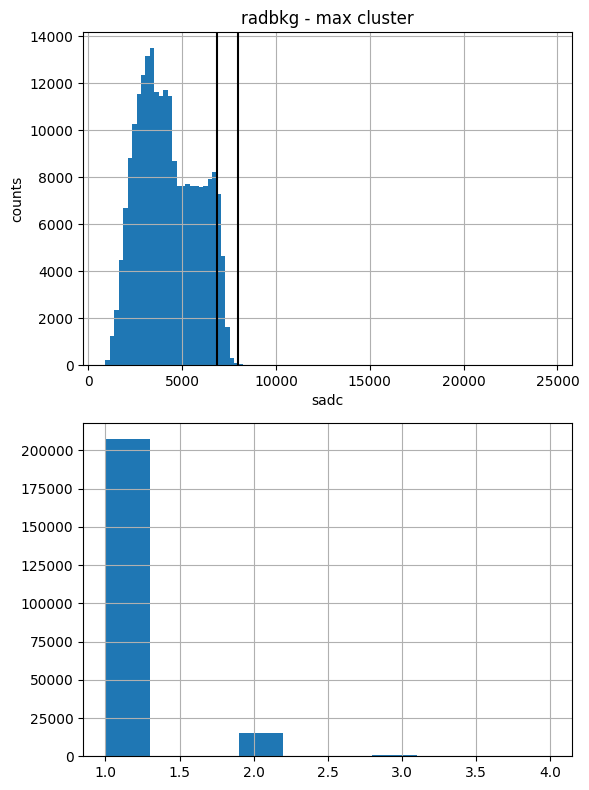

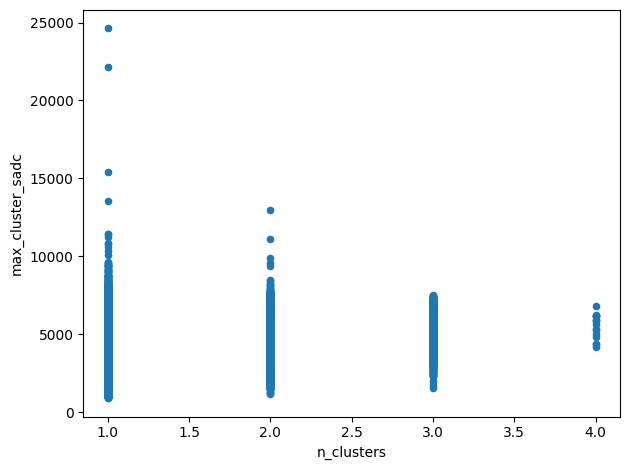

In [134]:
fig, axes = plt.subplots(2,1, figsize=(6,8))
ax=axes[0]
df.max_cluster_sadc.hist(bins=100, ax=ax)

sadc_1Mev = 2.2787e3
ax.axvline(x=sadc_1Mev*3.5, c='k')
ax.axvline(x=sadc_1Mev*3, c='k')
# ax.set_yscale('log')
ax.set_xlabel('sadc')
ax.set_ylabel('counts')
ax.set_title('radbkg - max cluster')

ax=axes[1]
df.n_clusters.hist(ax=ax)

fig.tight_layout()


fig, axes = plt.subplots(1,1)
ax=axes
df.plot.scatter(x='n_clusters', y='max_cluster_sadc', ax=ax)
fig.tight_layout()


In [73]:
rad_wins

,event_uid,TPCSetID,tawin_id,n_entries,sadc
0,233339401031,0,5,5,8382
1,233339401031,0,1,1,499
2,233339401031,0,7,3,3713
3,233339401031,0,2,3,4310
4,233339401031,0,6,8,14391
...,...,...,...,...,...
3511698,233789400095,47,4,2,2616
3511699,233789400095,47,7,6,14613
3511700,233789400095,47,3,3,3630
3511701,233789400095,47,6,2,1936


In [94]:
df = rad_wins

#----

import hist
xmin, xmax = df.sadc.min(), df.sadc.max()+1
bins=100

h = hist.Hist(hist.axis.Regular(bins, xmin, xmax), storage=hist.storage.Double())
h.fill(df.sadc.values)

Hist(Regular(100, 385, 42275, label='Axis 0'), storage=Double()) # Sum: 3511703.0

In [96]:
values = np.asarray(h.values(flow=False), dtype=float)
h1 = h / values.sum()
display(h1)


v = h1.values(flow=False)


Hist(Regular(100, 385, 42275, label='Axis 0'), storage=Double()) # Sum: 1.0

In [101]:
np.flip(np.cumsum(np.flip(v)))

array([1.00000000e+00, 9.68081298e-01, 9.15628685e-01, 8.76641903e-01,
       8.31470087e-01, 7.87530722e-01, 7.42836738e-01, 6.97651538e-01,
       6.53678002e-01, 6.11177540e-01, 5.69338580e-01, 5.29741838e-01,
       4.90892595e-01, 4.53193792e-01, 4.16737691e-01, 3.81336349e-01,
       3.47224979e-01, 3.15683018e-01, 2.86213555e-01, 2.59074871e-01,
       2.34044849e-01, 2.10744474e-01, 1.89481571e-01, 1.69893069e-01,
       1.51948499e-01, 1.35615398e-01, 1.20861588e-01, 1.07407147e-01,
       9.52890948e-02, 8.43416997e-02, 7.44507722e-02, 6.55607835e-02,
       5.76936603e-02, 5.06204540e-02, 4.43608130e-02, 3.88065278e-02,
       3.38283163e-02, 2.95036340e-02, 2.56006843e-02, 2.21983465e-02,
       1.92983290e-02, 1.67069937e-02, 1.44587968e-02, 1.24848257e-02,
       1.07557501e-02, 9.26815280e-03, 7.97533277e-03, 6.83856237e-03,
       5.85300067e-03, 5.01238288e-03, 4.28680899e-03, 3.65748470e-03,
       3.09337094e-03, 2.62892392e-03, 2.23993886e-03, 1.90847575e-03,
      

In [ ]:
h1.axes[0].edges()

array([  385. ,   803.9,  1222.8,  1641.7,  2060.6,  2479.5,  2898.4,
        3317.3,  3736.2,  4155.1,  4574. ,  4992.9,  5411.8,  5830.7,
        6249.6,  6668.5,  7087.4,  7506.3,  7925.2,  8344.1,  8763. ,
        9181.9,  9600.8, 10019.7, 10438.6, 10857.5, 11276.4, 11695.3,
       12114.2, 12533.1, 12952. , 13370.9, 13789.8, 14208.7, 14627.6,
       15046.5, 15465.4, 15884.3, 16303.2, 16722.1, 17141. , 17559.9,
       17978.8, 18397.7, 18816.6, 19235.5, 19654.4, 20073.3, 20492.2,
       20911.1, 21330. , 21748.9, 22167.8, 22586.7, 23005.6, 23424.5,
       23843.4, 24262.3, 24681.2, 25100.1, 25519. , 25937.9, 26356.8,
       26775.7, 27194.6, 27613.5, 28032.4, 28451.3, 28870.2, 29289.1,
       29708. , 30126.9, 30545.8, 30964.7, 31383.6, 31802.5, 32221.4,
       32640.3, 33059.2, 33478.1, 33897. , 34315.9, 34734.8, 35153.7,
       35572.6, 35991.5, 36410.4, 36829.3, 37248.2, 37667.1, 38086. ,
       38504.9, 38923.8, 39342.7, 39761.6, 40180.5, 40599.4, 41018.3,
       41437.2, 4185

In [117]:
hint = h1.copy()
x= hint.view(flow=False)
type(hint)

hist.hist.Hist

Hist(Regular(100, 385, 42275, label='Axis 0'), storage=Double()) # Sum: 14.213201970667791

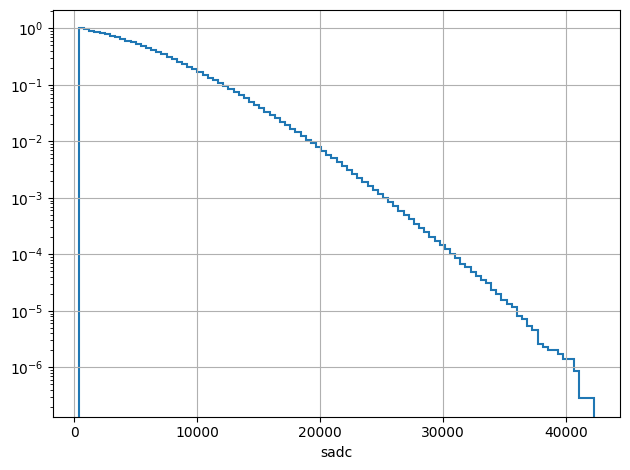

In [136]:
hint[:] = np.flip(np.cumsum(np.flip(v)))
display(hint)

import mplhep

fig,ax = plt.subplots()
mplhep.histplot(hint)
ax.set_yscale('log')
ax.grid()
ax.set_xlabel('sadc')
fig.tight_layout()

Search window rate 2000.0

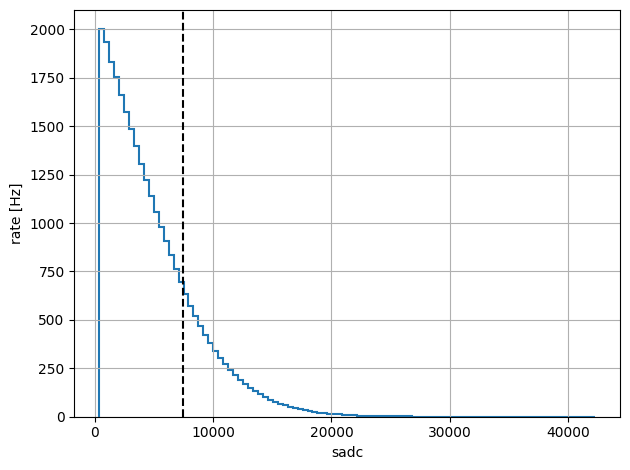

In [181]:
win_rate = 160*4/(0.5e-6*1000)
win_rate = 4/(0.5e-6*1000)
win_rate = 1/(0.5e-6*1000)
print(f" Search window rate {win_rate}")
fig,ax = plt.subplots()
mplhep.histplot(hint * win_rate)
# ax.set_yscale('log')
ax.grid()
ax.set_xlabel('sadc')
ax.set_ylabel('rate [Hz]')
ax.axvline(7500, c='k', ls='--')
fig.tight_layout()


